# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [70]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
# importar librerías

In [71]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [72]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [73]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [74]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [75]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [76]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [77]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [78]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [79]:
# cantidad de nulos para users
print(plans.isna().sum())# Cantidad de valores nulos)
print(plans.isna().mean())# Proporción de valores nulos)

plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [80]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean())# Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.
   Comentario: Se elimina normalmente, salvo casos donde la informacion se sea relevante.
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.
   Comentario: Se invenstiga para imputar. 
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
   Comentario: Se dejan como nulos. El porcentaje es muy pequeño para modificar la informacion.
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Comentario: No se encuentran nulos en las tablas generadas.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Comentario: Al no haber nulos, en estas tablas, no se toma esta decicion.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: confirma que la cuenta es correcta igual que age de 4000. 
- La columna `age`: lo que resalta es la minima de edad de -999 un numero imposible para edad.

In [15]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas: no encontramos nulos, 40,000 registros, rango de 10,000 a 13,999. 

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users["city"].unique())
print(users["plan"].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna `city`: se encuentran los paises Medellín, CDMX, Bogotá, GDL, MTY y Cali. Tambien se encontro ? y nan.
- La columna `plan`: se encuentra Basico y Premium. Si nulos.

In [17]:
# explorar columna categórica de usage
usage['type']
print(usage["type"].unique())# completa el código

['call' 'text']


- La columna `type`: call y text


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Comentario: en city, se encontraron valores invalidos, ? y nan.
- ¿Qué acción tomarías?
  estandarizar ? a nan, para saber exactamente cuantos datos invalidos tenemos. Ya tomar accion sobre ellos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")# completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
year_users = (users['reg_date'].dt.year.value_counts().sort_index())
print("Años en reg_date:")
print(year_users)

Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, 2026 no contaria ya que es fecha futura o en marcha.

In [21]:

# Revisar los años presentes en `date` de usage
year_usage = (usage['date'].dt.year.value_counts().sort_index())
print("Años en date:")
print(year_usage)


Años en date:
2024.0    39950
Name: date, dtype: int64


En `date`, 2024 tiene 39950 datos. La diferencia con el total es solo de 50, lo que no representa una afectacion al analisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Comentario: aparece año 2026, año que aun no transcurre.
- ¿Qué harías con ellas?
  Los convertimos en Nan, para identificarlos y diferenciarlos del resto que si se tomara en cuenta.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:

# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna(), margins=True))


duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna(), margins=True))

length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se confirma que los valores faltantes en duration y length son de tipo MAR. Los nulos en duration corresponden exclusivamente a mensajes de texto ('text'), mientras que los nulos en length corresponden a llamadas ('call'). Se dejan como estan.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg.columns=["user_id","cant_mensajes","cant_llamadas",
"cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
plan_distribution=user_profile["plan"].value_counts(normalize=True)*100
print(plan_distribution)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

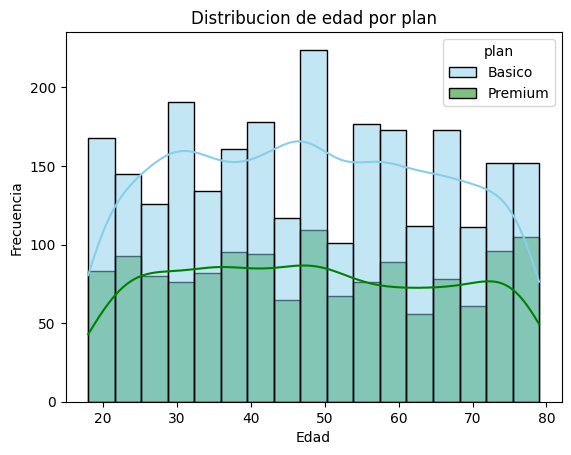

In [38]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile,x="age",hue='plan',palette=['skyblue','green'],kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribucion de edad por plan')
plt.show()


💡Insights: 
- Distribución: No se ve un patron claro, pero se observa que el plan Básico tiene una base de usuarios más grande en casi todos los rangos de edad.

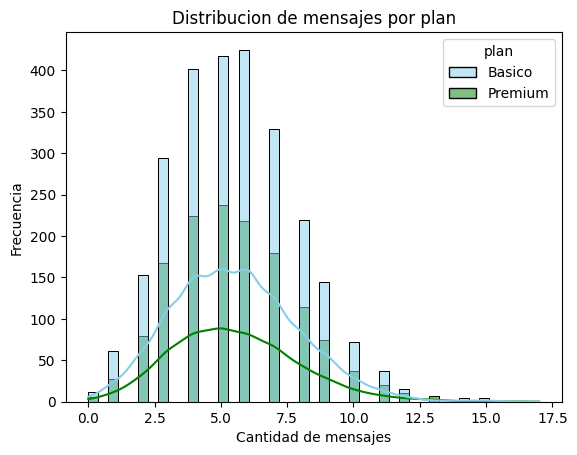

In [39]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile,x="cant_mensajes",hue='plan',palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribucion de mensajes por plan')
plt.show()


💡Insights: 
- Los usuarios del plan Básico tienden a enviar una menor cantidad de mensajes, mientras que en el plan Premium la distribución es más plana, sugiriendo que hay un grupo pequeño de usuarios que aprovecha el plan para enviar un volumen mucho mayor de mensajes.

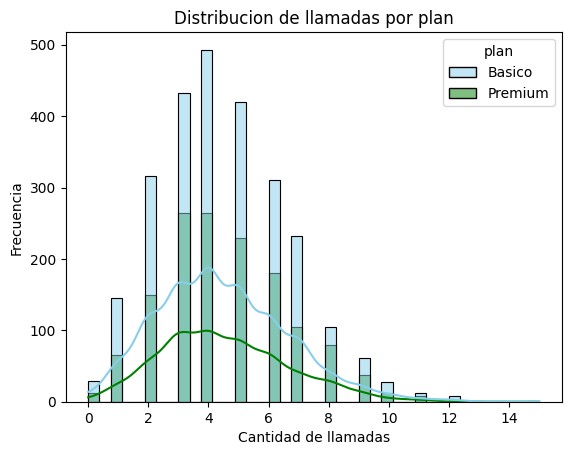

In [40]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile,x="cant_llamadas",hue='plan',palette=['skyblue','green'],kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.title('Distribucion de llamadas por plan')
plt.show()

💡Insights: 
- La distribución es sesgada a la derecha, lo que indica que la mayoría de los usuarios hace pocas llamadas y los casos de alta frecuencia son atípicos.

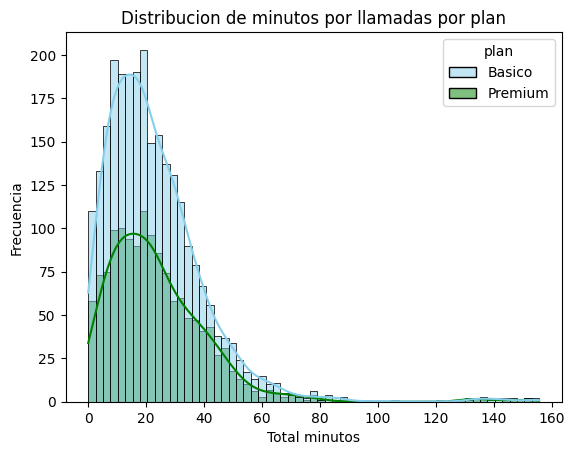

In [41]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_minutos_llamada",hue='plan',palette=['skyblue','green'],kde=True)
plt.xlabel('Total minutos')
plt.ylabel('Frecuencia')
plt.title('Distribucion de minutos por llamadas por plan')
plt.show()

💡Insights: 
- En ambos casos, cantidad y minutos, la distribución es sesgada a la derecha, con una concentración clara en llamadas cortas y frecuentes, y pocos usuarios realizando llamadas de larga duración.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

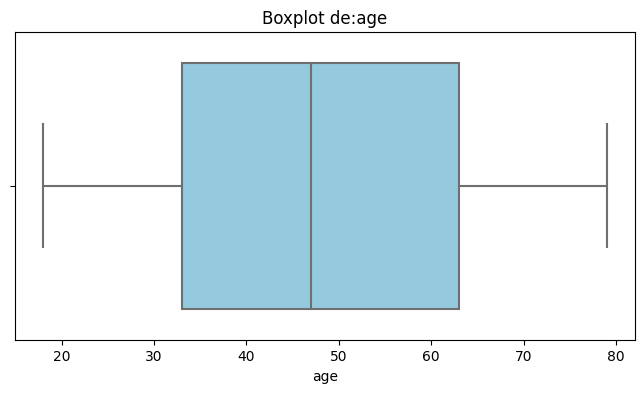

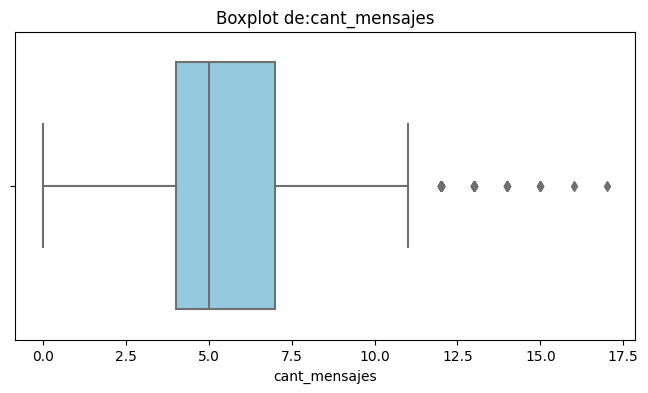

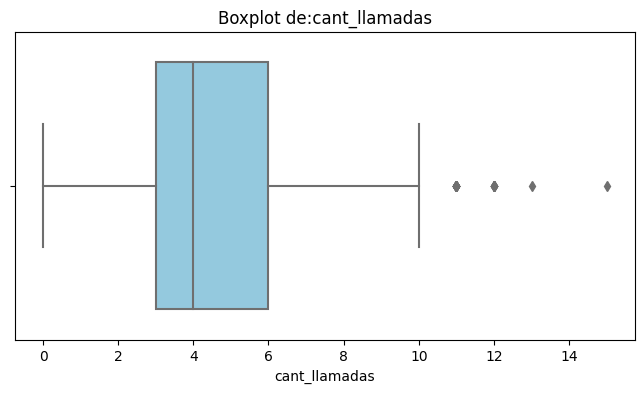

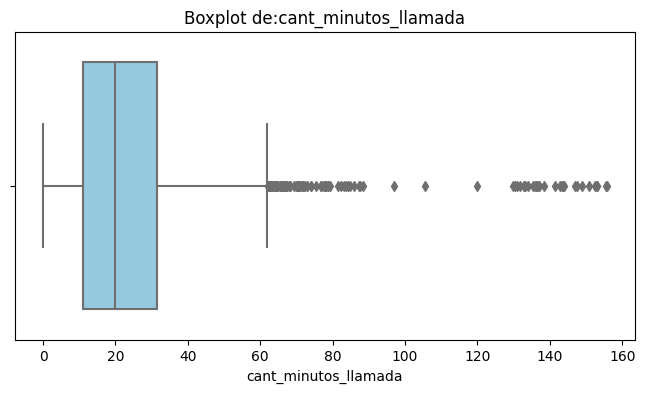

In [46]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=user_profile,x=col,color="skyblue")
    plt.title(f'Boxplot de:{col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers, la muestra de usuarios tiene una distribución de edad consistente y realista.
- cant_mensajes: Presenta outliers superiores, indicando usuarios con un uso de mensajería muy por encima de la media.
- cant_llamadas: Presenta outliers superiores leves; la frecuencia de llamadas es estable para la mayoría, con pocas excepciones de alta actividad.
- cant_minutos_llamada: Presenta una alta cantidad de outliers superiores, evidenciando que algunos usuarios consumen una cantidad excepcional de minutos en comparación con el comportamiento típico.

In [53]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites :
  Q1 = user_profile[col].quantile(0.25)
  Q3 = user_profile[col].quantile(0.75)
  IQR = Q3 - Q1
  limite_superior = Q3+1.5*IQR
  print(f'Columna:{col}')
  print(f'-IQR:{IQR}')
  print(f'-Limite Superior:{limite_superior}')
  print('-'*30)

Columna:age
-IQR:30.0
-Limite Superior:108.0
------------------------------
Columna:cant_mensajes
-IQR:3.0
-Limite Superior:11.5
------------------------------
Columna:cant_llamadas
-IQR:3.0
-Limite Superior:10.5
------------------------------
Columna:cant_minutos_llamada
-IQR:20.295
-Limite Superior:61.8575
------------------------------


In [54]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


##### 💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  Mantener: Los valores atípicos aquí representan a los usuarios de alto consumo. Son los que podrían migrar a planes más caros o los que ponen a prueba la capacidad de la red.
- cant_llamadas: mantener o no outliers, porqué?
  Mantener:un número alto de llamadas es un comportamiento comercialmente valioso. Eliminar estos datos sesgaría el cálculo de ingresos reales y la carga operativa de las antenas o centrales.
- cant_minutos_llamada: mantener o no outliers, porqué?
  Mantener:esta es la variable con más outliers, pero también es la que más dinero genera.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [57]:
# Crear columna grupo_uso
def segmentar_usuario(row):
    if row["cant_llamadas"]<5 and row ["cant_mensajes"]<5:
        return 'Bajo uso'
    elif row["cant_llamadas"]<10 and row ["cant_mensajes"]<10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile["grupo_uso"]= user_profile.apply(segmentar_usuario, axis=1)

In [59]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [60]:
# Crear columna grupo_edad

def segmentar_edad(row):
    if row["age"]<30:
        return 'Joven'
    elif row["age"]<60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile["grupo_edad"]= user_profile.apply(segmentar_edad, axis=1)


In [61]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

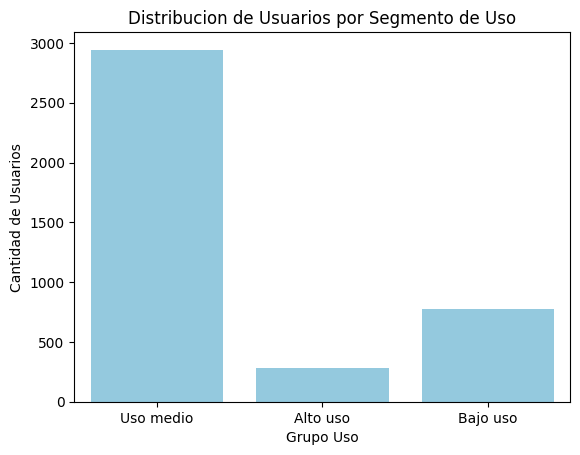

In [68]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x="grupo_uso",palette=["skyblue"])
plt.title("Distribucion de Usuarios por Segmento de Uso")
plt.xlabel("Grupo Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()

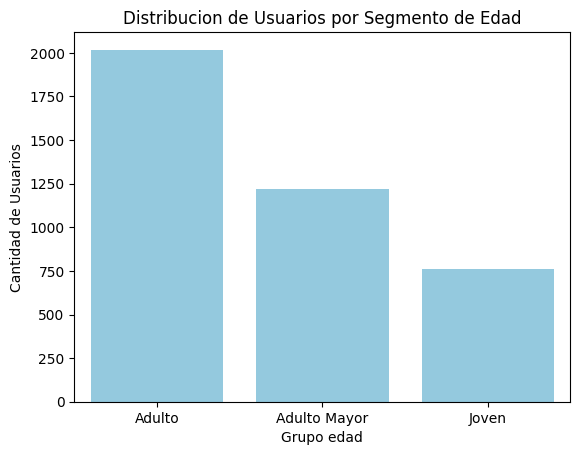

In [69]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x="grupo_edad",palette=["skyblue"])
plt.title("Distribucion de Usuarios por Segmento de Edad")
plt.xlabel("Grupo edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores ausentes NaN en columnas críticas como city  y churn_date. Los nulos en churn_date representan a los usuarios activos, lo cual es normal, pero los nulos en city requerían tratamiento para no sesgar el análisis regional.
- La columna reg_date presentaba formatos de fecha con microsegundos que necesitaban estandarización para cálculos temporales precisos.


🔍 **Segmentos por Edad**
- Es el grupo más numeroso con más de 2,000 usuarios, lo que indica que el grueso de la base de clientes está en una etapa de vida laboral activa.
- Los adultos mayores superan a los jóvenes en cantidad (aprox. 1,200 vs 750), lo que sugiere que ConnectaTel tiene una penetración de mercado más fuerte en generaciones establecidas que en el sector juvenil. 


📊 **Segmentos por Nivel de Uso**
- La gran mayoría de los clientes caen en esta categoría, lo que indica un comportamiento de consumo estandarizado y predecible.
- El segmento de usuarios intensivos es el más pequeño, representando una oportunidad de crecimiento o un nicho premium muy específico.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- La baja cantidad de usuarios "Joven" sugiere que la oferta actual no es atractiva para ellos. Se recomienda lanzar un plan para aumentar la participación en este sector.
- Implementar campañas con beneficios incrementales para mover a la gran masa de usuarios de la categoría media a la superior.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`